In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
def femcode1d(p, f, alfa, beta):
    """
    Solución de la ecuación -u'' = f en 1D con condiciones 
    g(x_0)=alfa, g'(x_N)=beta.
    p: Array de coordenadas 1D de los nodos [x_0, x_1, ..., x_N]
    f: Función fuente f(x)
    alfa: Valor de frontera en x_0
    beta: valor de derivada en x_N
    """
    n = len(p)
    T = n - 1  # Número de elementos
    t = np.column_stack((np.arange(0, T), np.arange(1, n)))  # Elementos 1D (pares de nodos)
    b = np.array([0])  # Nodos de la frontera (extremos)

    K = np.zeros((n, n))
    F = np.zeros(n)

    for e in range(T):
        nodes = t[e]
        x_e = p[nodes]
        h = np.abs(x_e[1] - x_e[0])  # Longitud del elemento

        # Matriz de rigidez elemental (derivadas)
        Pe=np.hstack((np.ones((2,1)),x_e.reshape(2,1)))
        Area = np.linalg.det(Pe)/1.0
        C=np.linalg.inv(Pe)
        grad=C[1,:]

        Ke_stiff = Area*np.outer(grad, grad)  # Producto externo para la matriz de rigidez

        Ke = Ke_stiff 

        # Vector de carga elemental (aproximación por punto medio)
        x_mid = np.mean(x_e)
        Fe = (Area / 2.0) * f(x_mid) * np.array([1.0, 1.0])

        # Ensamblaje global correcto
        K[np.ix_(nodes, nodes)] += Ke
        F[nodes] += Fe

    # Condiciones de frontera de Dirichlet
    u_b = g(p[b])
    # Condiciones de frontera de Neumann
    F[n-1] += beta

    # Ajustar F con las contribuciones conocidas de la frontera
    F -= K[:, b] @ u_b

    # Imponer valores conocidos en la matriz K y vector F
    for idx, node in enumerate(b):
        K[node, :] = 0.0
        K[:, node] = 0.0
        K[node, node] = 1.0
        F[node] = u_b[idx]

    # Resolver el sistema K * U = F
    U = np.linalg.solve(K, F)

    return U, K, F


In [21]:
def f(x): return np.pi**2/4*np.sin(np.pi*x/2)
def g(x): return np.sin(np.pi*x/2)

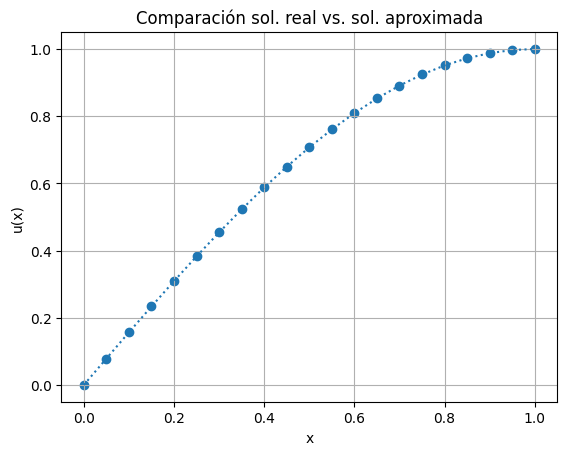

In [22]:
x=np.linspace(0,1,21)

U,_,_=femcode1d(x,f,0,0)

plt.scatter(x,g(x))
plt.plot(x,U,label="aprox", linestyle=':')
#plt.plot(x,np.fabs(U-U_i))

plt.xlabel('x')
plt.ylabel('u(x)')
titulo='Comparación sol. real vs. sol. aproximada'
plt.title(titulo)

plt.grid()
plt.show()